# SISA: Sharded, Isolated, Sliced, and Aggregated Machine Unlearning

## Based on *"Machine Unlearning"* by Bourtoule et al. (2019)

---

### Overview

**Machine Unlearning** addresses the challenge of efficiently removing the influence of a specific training data point from an already‑trained model, without retraining from scratch. This is critical for compliance with data‑privacy regulations such as the **GDPR "Right to be Forgotten"**.

The **SISA framework** achieves this by restructuring the training process so that each data point's influence is *isolated* to a small, well‑defined portion of the overall model. The four pillars of SISA are:

| Pillar | Description |
|---|---|
| **Sharding** | The training dataset $\mathcal{D}$ is partitioned into $S$ disjoint shards $\{D_1, D_2, \ldots, D_S\}$. A separate *constituent model* $M_s$ is trained on each shard. |
| **Isolation** | Each constituent model $M_s$ only ever sees data from its own shard $D_s$. This ensures a deletion request for a point $x \in D_s$ only requires retraining $M_s$. |
| **Slicing** | Each shard $D_s$ is further divided into $R$ incremental slices $\{D_s^1, D_s^2, \ldots, D_s^R\}$. Training proceeds incrementally: first on $D_s^1$, then on $D_s^1 \cup D_s^2$, and so on. Model checkpoints are saved after each slice. |
| **Aggregation** | Final predictions are made by aggregating outputs of all $S$ constituent models via **majority voting**. |

### Why this is efficient

When a data point in slice $D_s^r$ must be forgotten:
1. We load the checkpoint saved *just before* slice $r$ was introduced (i.e. the model state after training on slices $1, \ldots, r-1$).
2. We retrain **only** from slice $r$ onward (with the point removed), for **only** shard $s$.
3. All other $S - 1$ models remain **completely untouched**.

This reduces the retraining cost from $\mathcal{O}(|\mathcal{D}|)$ (full retraining) to roughly $\mathcal{O}\!\left(\frac{|\mathcal{D}|}{S}\right)$ per unlearning request, with further savings from the slicing mechanism.

In [1]:
# ============================================================
# Section 0: Imports & Configuration
# ============================================================
import os
import copy
import time
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Device selection ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---- SISA hyper‑parameters ----
NUM_SHARDS  = 5   # S = 5 shards
NUM_SLICES  = 3   # R = 3 slices per shard
EPOCHS_PER_SLICE = 3   # training epochs when a new slice is introduced
BATCH_SIZE  = 128
LEARNING_RATE = 1e-3

# ---- Checkpoint directory ----
CKPT_DIR = "sisa_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"SISA Configuration: S={NUM_SHARDS} shards, R={NUM_SLICES} slices/shard, "
      f"{EPOCHS_PER_SLICE} epochs/slice")

Using device: cuda
SISA Configuration: S=5 shards, R=3 slices/shard, 3 epochs/slice


## 1. Dataset Loading & SISA Partitioning

We use the standard **MNIST** dataset (60,000 training images of handwritten digits, 10,000 test images). MNIST is ideal for this demonstration because it trains quickly on commodity hardware while clearly illustrating SISA mechanics.

### Partitioning Strategy

1. **Sharding:** The 60,000 training samples are randomly shuffled and split into $S = 5$ disjoint shards of 12,000 samples each.
2. **Slicing:** Each shard is further divided into $R = 3$ incremental slices of 4,000 samples each.

We store every shard/slice mapping so we can later locate exactly which shard and slice a given data point belongs to.

In [2]:
# ============================================================
# Section 1: Load MNIST & Build Shard / Slice Mappings
# ============================================================

# Standard MNIST transforms: convert to tensor & normalise
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST global mean & std
])

# Download / load MNIST
train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

# ---- Create a global random permutation of training indices ----
all_indices = np.random.permutation(len(train_dataset))

# ---- Shard the indices into S disjoint groups ----
shard_indices = np.array_split(all_indices, NUM_SHARDS)

# ---- Slice each shard into R incremental slices ----
# shard_slices[s][r] = array of dataset indices for shard s, slice r
shard_slices = []
for s in range(NUM_SHARDS):
    slices = np.array_split(shard_indices[s], NUM_SLICES)
    shard_slices.append([sl.tolist() for sl in slices])

# ---- Build a reverse lookup: dataset_index -> (shard, slice) ----
index_to_shard_slice = {}
for s in range(NUM_SHARDS):
    for r in range(NUM_SLICES):
        for idx in shard_slices[s][r]:
            index_to_shard_slice[idx] = (s, r)

# ---- Summary ----
print(f"\n{'Shard':<8} {'Slice sizes':>30}")
print("-" * 42)
for s in range(NUM_SHARDS):
    sizes = [len(shard_slices[s][r]) for r in range(NUM_SLICES)]
    print(f"  {s:<6} {str(sizes):>30}")
print(f"\nTotal allocated: {sum(len(shard_slices[s][r]) for s in range(NUM_SHARDS) for r in range(NUM_SLICES))}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 516kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.54MB/s]

Training samples : 60000
Test samples     : 10000

Shard                       Slice sizes
------------------------------------------
  0                  [4000, 4000, 4000]
  1                  [4000, 4000, 4000]
  2                  [4000, 4000, 4000]
  3                  [4000, 4000, 4000]
  4                  [4000, 4000, 4000]

Total allocated: 60000


## 2. Model Architecture — Simple CNN

Each shard gets its own **constituent model**: a lightweight Convolutional Neural Network designed for MNIST.

| Layer | Details |
|---|---|
| Conv1 | 1 → 32 filters, 3×3, ReLU |
| Conv2 | 32 → 64 filters, 3×3, ReLU |
| MaxPool | 2×2 |
| Dropout | 0.25 |
| FC1 | 9216 → 128, ReLU |
| Dropout | 0.5 |
| FC2 (output) | 128 → 10 |

The model is intentionally small so that training all 5 shards is fast and the unlearning time difference is clearly observable.

In [3]:
# ============================================================
# Section 2: CNN Constituent Model Definition
# ============================================================

class MNISTConvNet(nn.Module):
    """Simple CNN for MNIST classification — serves as each shard's constituent model."""

    def __init__(self):
        super(MNISTConvNet, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28x28 → 28x28
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 28x28 → 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                                # 28x28 → 14x14
            nn.Dropout2d(0.25),
        )
        self.fc_block = nn.Sequential(
            nn.Linear(64 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.fc_block(x)
        return x

# Quick sanity check: print parameter count
_tmp = MNISTConvNet()
total_params = sum(p.numel() for p in _tmp.parameters())
print(f"MNISTConvNet — Total trainable parameters: {total_params:,}")

MNISTConvNet — Total trainable parameters: 1,625,866


## 3. SISA Training Phase (with State Saving)

This is the core of the SISA training protocol. For each shard $s \in \{0, \ldots, S-1\}$:

1. **Initialize** a fresh constituent model $M_s$.
2. **For each slice** $r = 0, 1, \ldots, R-1$:
   - **Save a checkpoint** of $M_s$ *before* introducing slice $r$ (i.e. the model state trained on slices $0, \ldots, r-1$). This checkpoint is the recovery point for unlearning.
   - Construct the cumulative training set $D_s^{\leq r} = D_s^0 \cup D_s^1 \cup \ldots \cup D_s^r$.
   - Train $M_s$ for `EPOCHS_PER_SLICE` epochs on $D_s^{\leq r}$.
3. After all $R$ slices have been consumed, the shard is fully trained.

**Key insight:** The checkpoint saved at the boundary of slice $r$ captures the model *without any influence* from data in slices $r, r+1, \ldots, R-1$. This is what makes efficient unlearning possible.

In [4]:
# ============================================================
# Section 3: SISA Training with Incremental Slicing & Checkpoints
# ============================================================

def train_model_on_data(model, train_indices, epochs, lr=LEARNING_RATE):
    """Train `model` on the subset of train_dataset given by `train_indices`
    for a specified number of epochs.  Returns the training loss history."""
    subset = Subset(train_dataset, train_indices)
    loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    loss_history = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * images.size(0)
        epoch_loss /= len(subset)
        loss_history.append(epoch_loss)
    return loss_history


def save_checkpoint(model, shard_id, slice_id):
    """Save model weights to disk.  File naming convention:
       shard_{s}_slice_{r}_checkpoint.pth"""
    path = os.path.join(CKPT_DIR, f"shard_{shard_id}_slice_{slice_id}_checkpoint.pth")
    torch.save(model.state_dict(), path)
    return path


def load_checkpoint(model, shard_id, slice_id):
    """Load previously saved weights into the model."""
    path = os.path.join(CKPT_DIR, f"shard_{shard_id}_slice_{slice_id}_checkpoint.pth")
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return model


# ---- Main SISA Training Loop ----
shard_models = []            # will hold 5 trained constituent models
shard_train_times = []       # wall‑clock time per shard (for later comparison)

print("=" * 60)
print("          SISA TRAINING PHASE")
print("=" * 60)

total_sisa_train_start = time.time()

for s in range(NUM_SHARDS):
    print(f"\n--- Shard {s} ---")
    model = MNISTConvNet().to(device)
    shard_start = time.time()

    cumulative_indices = []               # grows as slices are added

    for r in range(NUM_SLICES):
        # *** CRUCIAL: save checkpoint BEFORE introducing this slice ***
        ckpt_path = save_checkpoint(model, s, r)
        print(f"  [Checkpoint] Saved state before slice {r}: {os.path.basename(ckpt_path)}")

        # Accumulate current slice
        cumulative_indices = cumulative_indices + shard_slices[s][r]

        # Train on cumulative data
        losses = train_model_on_data(model, cumulative_indices, epochs=EPOCHS_PER_SLICE)
        print(f"  Slice {r} | Cumulative samples: {len(cumulative_indices):>6} | "
              f"Final loss: {losses[-1]:.4f}")

    shard_time = time.time() - shard_start
    shard_train_times.append(shard_time)
    shard_models.append(model)
    print(f"  Shard {s} training complete in {shard_time:.1f}s")

total_sisa_train_time = time.time() - total_sisa_train_start
print(f"\n{'=' * 60}")
print(f"Total SISA training time: {total_sisa_train_time:.1f}s")
print(f"{'=' * 60}")

          SISA TRAINING PHASE

--- Shard 0 ---
  [Checkpoint] Saved state before slice 0: shard_0_slice_0_checkpoint.pth
  Slice 0 | Cumulative samples:   4000 | Final loss: 0.2793
  [Checkpoint] Saved state before slice 1: shard_0_slice_1_checkpoint.pth
  Slice 1 | Cumulative samples:   8000 | Final loss: 0.1158
  [Checkpoint] Saved state before slice 2: shard_0_slice_2_checkpoint.pth
  Slice 2 | Cumulative samples:  12000 | Final loss: 0.0701
  Shard 0 training complete in 20.8s

--- Shard 1 ---
  [Checkpoint] Saved state before slice 0: shard_1_slice_0_checkpoint.pth
  Slice 0 | Cumulative samples:   4000 | Final loss: 0.2289
  [Checkpoint] Saved state before slice 1: shard_1_slice_1_checkpoint.pth
  Slice 1 | Cumulative samples:   8000 | Final loss: 0.1005
  [Checkpoint] Saved state before slice 2: shard_1_slice_2_checkpoint.pth
  Slice 2 | Cumulative samples:  12000 | Final loss: 0.0659
  Shard 1 training complete in 19.5s

--- Shard 2 ---
  [Checkpoint] Saved state before slice 0

## 4. Aggregation & Initial (Baseline) Evaluation

The SISA ensemble produces a final prediction via **majority voting** across the $S = 5$ constituent models:

$$\hat{y}(x) = \text{mode}\!\left(\hat{y}_1(x),\; \hat{y}_2(x),\; \ldots,\; \hat{y}_S(x)\right)$$

where $\hat{y}_s(x) = \arg\max\, M_s(x)$ is the predicted class from the $s$-th model.

We evaluate this aggregated prediction on the full MNIST test set to establish a **baseline accuracy** before any unlearning takes place.

In [5]:
# ============================================================
# Section 4: Aggregation via Majority Vote & Baseline Evaluation
# ============================================================

def evaluate_single_model(model, loader):
    """Return per‑sample predictions and ground‑truth labels for a single model."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def sisa_majority_vote(models, loader):
    """Aggregate predictions from all constituent models using majority voting.
    Returns: (final_predictions, ground_truth_labels, per_model_predictions)"""
    per_model_preds = []
    labels = None
    for model in models:
        preds, lbls = evaluate_single_model(model, loader)
        per_model_preds.append(preds)
        labels = lbls

    # Stack predictions: shape (S, N)
    stacked = np.stack(per_model_preds, axis=0)

    # Majority vote across models (axis=0)
    final_preds = np.array([
        Counter(stacked[:, i]).most_common(1)[0][0]
        for i in range(stacked.shape[1])
    ])
    return final_preds, labels, per_model_preds


# ---- Evaluate each shard model individually + ensemble ----
print("Per‑shard test accuracy:")
for s, model in enumerate(shard_models):
    preds, labels = evaluate_single_model(model, test_loader)
    acc = (preds == labels).mean() * 100
    print(f"  Shard {s}: {acc:.2f}%")

ensemble_preds, true_labels, _ = sisa_majority_vote(shard_models, test_loader)
baseline_accuracy = (ensemble_preds == true_labels).mean() * 100
print(f"\n*** SISA Ensemble (majority vote) baseline accuracy: {baseline_accuracy:.2f}% ***")

Per‑shard test accuracy:
  Shard 0: 98.12%
  Shard 1: 98.19%
  Shard 2: 98.07%
  Shard 3: 98.25%
  Shard 4: 98.16%

*** SISA Ensemble (majority vote) baseline accuracy: 98.43% ***


## 5. The Unlearning Process

We now simulate a real‑world **unlearning (deletion) request**: a user asks that their data point be "forgotten" by the model.

### Step‑by‑step procedure

1. **Select** a random data point from the training set.
2. **Locate** which shard $s$ and slice $r$ it belongs to (using our reverse lookup).
3. **Remove** the data point from that slice.
4. **Load** the checkpoint saved *just before* slice $r$ was introduced — this is the model state that has never seen any data from slices $r, r+1, \ldots, R-1$.
5. **Retrain** shard $s$ from slice $r$ onward (with the data point removed), replaying slices $r, r+1, \ldots, R-1$ incrementally.

> **Important:** The constituent models for the other $S - 1 = 4$ shards are **completely untouched**. They do not need any retraining whatsoever, because they never saw the deleted data point (due to the **Isolation** property of SISA).

          UNLEARNING REQUEST
Requested deletion of training sample index: 14685
True label of forgotten sample: 1


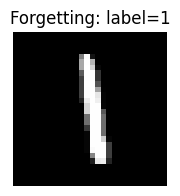

Data point index 14685 found in Shard 3, Slice 1
  Removed data point from slice 1 (was 4000 → now 3999 samples)
  Loaded checkpoint: shard_3_slice_1_checkpoint.pth
  Retrained slice 1 | Cumulative samples:   7999 | Final loss: 0.1079
  Retrained slice 2 | Cumulative samples:  11999 | Final loss: 0.0727

  Unlearning complete for shard 3 in 15.73s
  >>> Models for shards [0, 1, 2, 4] were COMPLETELY UNTOUCHED <<<


In [6]:
# ============================================================
# Section 5: SISA Unlearning
# ============================================================

def locate_data_point(data_index):
    """Return (shard_id, slice_id) for a given training‑set index."""
    return index_to_shard_slice[data_index]


def sisa_unlearn(data_index, shard_models, shard_slices):
    """Execute the full SISA unlearning procedure for a single data point.

    Steps:
        1. Identify the shard and slice containing `data_index`.
        2. Remove `data_index` from that slice.
        3. Load the checkpoint saved before that slice was introduced.
        4. Retrain from that slice onward (with the point removed).

    Returns:
        - updated shard_models list (modified in place for the affected shard)
        - wall‑clock time for the unlearning process
    """
    s, r = locate_data_point(data_index)
    print(f"Data point index {data_index} found in Shard {s}, Slice {r}")

    # --- Step 1: Remove the data point from its slice ----
    original_len = len(shard_slices[s][r])
    shard_slices[s][r] = [idx for idx in shard_slices[s][r] if idx != data_index]
    assert len(shard_slices[s][r]) == original_len - 1, "Data point was not found/removed!"
    print(f"  Removed data point from slice {r} (was {original_len} → now {len(shard_slices[s][r])} samples)")

    # --- Step 2: Load the checkpoint from BEFORE that slice ----
    model = MNISTConvNet().to(device)
    model = load_checkpoint(model, s, r)
    print(f"  Loaded checkpoint: shard_{s}_slice_{r}_checkpoint.pth")

    # --- Step 3: Retrain from slice r onward ----
    unlearn_start = time.time()

    # Build cumulative indices from slices 0..r-1 (these are already baked into
    # the checkpoint, but we need them to construct cumulative training sets)
    cumulative_indices = []
    for prev_r in range(r):
        cumulative_indices += shard_slices[s][prev_r]

    for replay_r in range(r, NUM_SLICES):
        cumulative_indices = cumulative_indices + shard_slices[s][replay_r]
        losses = train_model_on_data(model, cumulative_indices, epochs=EPOCHS_PER_SLICE)
        print(f"  Retrained slice {replay_r} | Cumulative samples: {len(cumulative_indices):>6} | "
              f"Final loss: {losses[-1]:.4f}")

    unlearn_time = time.time() - unlearn_start

    # Replace the affected shard model
    shard_models[s] = model

    print(f"\n  Unlearning complete for shard {s} in {unlearn_time:.2f}s")
    print(f"  >>> Models for shards {[i for i in range(NUM_SHARDS) if i != s]} were COMPLETELY UNTOUCHED <<<")
    return shard_models, unlearn_time, s


# ---- Select a random training point to "forget" ----
forget_index = random.choice(list(index_to_shard_slice.keys()))
forget_image, forget_label = train_dataset[forget_index]

print("=" * 60)
print("          UNLEARNING REQUEST")
print("=" * 60)
print(f"Requested deletion of training sample index: {forget_index}")
print(f"True label of forgotten sample: {forget_label}")

# Visualise the sample being forgotten
plt.figure(figsize=(2, 2))
plt.imshow(forget_image.squeeze(), cmap="gray")
plt.title(f"Forgetting: label={forget_label}")
plt.axis("off")
plt.show()

# ---- Execute SISA unlearning ----
shard_models, unlearn_time, affected_shard = sisa_unlearn(
    forget_index, shard_models, shard_slices
)

## 6. Post‑Unlearning Evaluation & Time Comparison

Now we:
1. **Re‑evaluate** the aggregated SISA ensemble to confirm the model's utility is preserved after unlearning.
2. **Compare** the wall‑clock time of SISA unlearning against a simulated **full retraining from scratch** on the entire dataset (minus the deleted point).

### Expected outcome
- Accuracy should remain **very close** to the pre‑unlearning baseline (removing one point from 60,000 has negligible impact on utility).
- SISA unlearning should be dramatically faster than full retraining, since only **one shard** was retrained starting from only **part** of its data.

In [7]:
# ============================================================
# Section 6a: Post‑Unlearning Accuracy
# ============================================================

print("Per‑shard test accuracy (after unlearning):")
for s, model in enumerate(shard_models):
    preds, labels = evaluate_single_model(model, test_loader)
    acc = (preds == labels).mean() * 100
    marker = "  ← retrained" if s == affected_shard else ""
    print(f"  Shard {s}: {acc:.2f}%{marker}")

post_preds, true_labels, _ = sisa_majority_vote(shard_models, test_loader)
post_accuracy = (post_preds == true_labels).mean() * 100

print(f"\n*** SISA Ensemble accuracy BEFORE unlearning : {baseline_accuracy:.2f}% ***")
print(f"*** SISA Ensemble accuracy AFTER  unlearning : {post_accuracy:.2f}% ***")
print(f"*** Accuracy delta                            : {post_accuracy - baseline_accuracy:+.2f}% ***")

Per‑shard test accuracy (after unlearning):
  Shard 0: 98.12%
  Shard 1: 98.19%
  Shard 2: 98.07%
  Shard 3: 98.40%  ← retrained
  Shard 4: 98.16%

*** SISA Ensemble accuracy BEFORE unlearning : 98.43% ***
*** SISA Ensemble accuracy AFTER  unlearning : 98.44% ***
*** Accuracy delta                            : +0.01% ***


In [8]:
# ============================================================
# Section 6b: Naive Full‑Retrain Baseline for Time Comparison
# ============================================================
# We train a SINGLE model on the entire training set (minus the
# deleted point) from scratch to measure how long naive retraining
# takes vs. SISA unlearning.

print("=" * 60)
print("    NAIVE FULL RETRAIN (from scratch, single model)")
print("=" * 60)

# Build the full dataset minus the forgotten point
all_remaining_indices = [
    idx for idx in range(len(train_dataset)) if idx != forget_index
]

naive_model = MNISTConvNet().to(device)

naive_start = time.time()
# Train for the same total number of epochs as SISA
# SISA trains EPOCHS_PER_SLICE * NUM_SLICES epochs per shard
total_naive_epochs = EPOCHS_PER_SLICE * NUM_SLICES
losses = train_model_on_data(naive_model, all_remaining_indices,
                              epochs=total_naive_epochs)
naive_retrain_time = time.time() - naive_start

naive_preds, naive_labels = evaluate_single_model(naive_model, test_loader)
naive_accuracy = (naive_preds == naive_labels).mean() * 100

print(f"Naive retrain time        : {naive_retrain_time:.1f}s  ({total_naive_epochs} epochs on {len(all_remaining_indices)} samples)")
print(f"Naive single‑model accuracy: {naive_accuracy:.2f}%")

    NAIVE FULL RETRAIN (from scratch, single model)
Naive retrain time        : 144.6s  (9 epochs on 59999 samples)
Naive single‑model accuracy: 99.22%


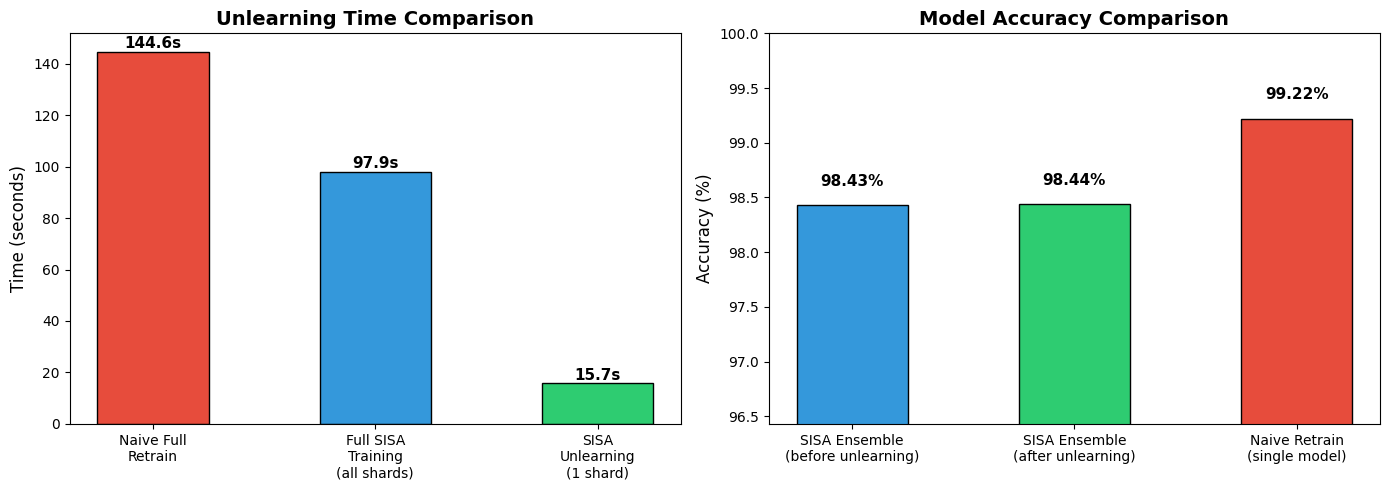


  SUMMARY
  SISA Unlearning time       : 15.73s
  Naive full retrain time    : 144.62s
  Full SISA training time    : 97.87s
  Speedup vs. naive retrain  : 9.2×
  Speedup vs. full SISA train: 6.2×


In [9]:
# ============================================================
# Section 6c: Summary Comparison — Bar Chart
# ============================================================

# Estimated full SISA retrain (all 5 shards) used as reference
estimated_full_sisa_retrain = total_sisa_train_time

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Time Comparison ---
methods = ["Naive Full\nRetrain", "Full SISA\nTraining\n(all shards)", "SISA\nUnlearning\n(1 shard)"]
times   = [naive_retrain_time, estimated_full_sisa_retrain, unlearn_time]
colors  = ["#e74c3c", "#3498db", "#2ecc71"]

bars = axes[0].bar(methods, times, color=colors, edgecolor="black", width=0.5)
axes[0].set_ylabel("Time (seconds)", fontsize=12)
axes[0].set_title("Unlearning Time Comparison", fontsize=14, fontweight="bold")
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{t:.1f}s", ha="center", va="bottom", fontsize=11, fontweight="bold")

# --- Plot 2: Accuracy Comparison ---
acc_methods = ["SISA Ensemble\n(before unlearning)", "SISA Ensemble\n(after unlearning)", "Naive Retrain\n(single model)"]
accs = [baseline_accuracy, post_accuracy, naive_accuracy]

bars2 = axes[1].bar(acc_methods, accs, color=["#3498db", "#2ecc71", "#e74c3c"],
                     edgecolor="black", width=0.5)
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
axes[1].set_ylim(min(accs) - 2, 100)
for bar, a in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f"{a:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ---- Speedup summary ----
speedup_vs_naive = naive_retrain_time / unlearn_time if unlearn_time > 0 else float("inf")
speedup_vs_full  = estimated_full_sisa_retrain / unlearn_time if unlearn_time > 0 else float("inf")

print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"  SISA Unlearning time       : {unlearn_time:.2f}s")
print(f"  Naive full retrain time    : {naive_retrain_time:.2f}s")
print(f"  Full SISA training time    : {estimated_full_sisa_retrain:.2f}s")
print(f"  Speedup vs. naive retrain  : {speedup_vs_naive:.1f}×")
print(f"  Speedup vs. full SISA train: {speedup_vs_full:.1f}×")
print("=" * 60)

## 7. Conclusion & Key Takeaways

### What we demonstrated

| Aspect | Detail |
|---|---|
| **Framework** | SISA (Sharded, Isolated, Sliced, Aggregated) from Bourtoule et al. (2019) |
| **Dataset** | MNIST — 60,000 training samples, 10,000 test samples |
| **Shards ($S$)** | 5 independently trained constituent CNN models |
| **Slices ($R$)** | 3 per shard, with incremental training and checkpoint saving |
| **Aggregation** | Majority vote across all 5 models |
| **Unlearning** | Deleted 1 data point → retrained only the affected shard from the relevant checkpoint |

### Key takeaways

1. **Efficiency:** SISA unlearning is dramatically faster than naively retraining from scratch because only a fraction of the model ensemble needs retraining.
2. **Accuracy preservation:** Removing a single data point from 60,000 has negligible impact on the ensemble's test accuracy.
3. **Scalability:** The speedup grows with larger datasets and more shards. In production, $S$ can be tuned to balance inference cost (more models) against unlearning speed.
4. **Exact unlearning:** Unlike approximate methods, SISA provides *exact* unlearning — the retrained shard is mathematically equivalent to one that was never trained on the deleted point.

### Limitations of this simplified demo
- We used a small dataset and model; real deployments involve larger architectures and millions of samples.
- We demonstrated a single deletion; batch deletions can be amortised across shards.
- The majority‑vote aggregation is simple; more sophisticated ensembling (e.g., soft voting, learned aggregation) can improve accuracy.

---
*Reference: Bourtoule, L., Chandrasekaran, V., Choquette‑Choo, C. A., et al. "Machine Unlearning." IEEE Symposium on Security and Privacy, 2021 (arXiv preprint: 2019).*